In [1]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the spam dataset

df = pd.read_csv("spam.csv", encoding="latin-1")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Display the first 5 rows

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# Check column names

print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [6]:
# Keep only the useful columns

df = df[["v1", "v2"]]

# Rename columns for better understanding

df.columns = ["label", "message"]

print("Extra columns removed successfully!")

Extra columns removed successfully!


In [7]:
# Check for missing values

print(df.isnull().sum())

label      0
message    0
dtype: int64


In [8]:
# Check the number of spam and ham messages

print(df["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Matplotlib and Seaborn imported successfully!")

Matplotlib and Seaborn imported successfully!


In [12]:
# Text preprocessing

df["message"] = df["message"].str.lower()

print("Text preprocessing completed!")
print(df.head())

Text preprocessing completed!
  label                                            message
0   ham  go until jurong point, crazy.. available only ...
1   ham                      ok lar... joking wif u oni...
2  spam  free entry in 2 a wkly comp to win fa cup fina...
3   ham  u dun say so early hor... u c already then say...
4   ham  nah i don't think he goes to usf, he lives aro...


In [13]:
# Convert labels into numerical values

df["label"] = df["label"].map({"ham": 0, "spam": 1})

print("Labels converted successfully!")
print(df.head())

Labels converted successfully!
   label                                            message
0      0  go until jurong point, crazy.. available only ...
1      0                      ok lar... joking wif u oni...
2      1  free entry in 2 a wkly comp to win fa cup fina...
3      0  u dun say so early hor... u c already then say...
4      0  nah i don't think he goes to usf, he lives aro...


In [14]:
from sklearn.model_selection import train_test_split

X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-Test split completed!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Train-Test split completed!
Training samples: 4457
Testing samples: 1115


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF vectorization completed!")
print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

TF-IDF vectorization completed!
Training data shape: (4457, 7701)
Testing data shape: (1115, 7701)


In [16]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [17]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9605381165919282

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.70      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



In [18]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [19]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9721973094170404

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.80      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



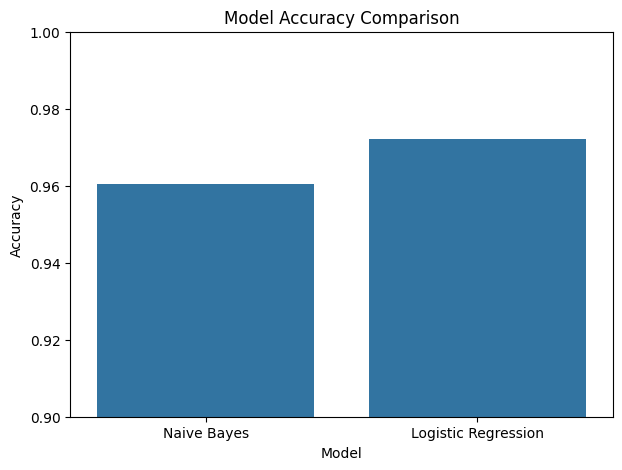

In [20]:
# Compare model accuracy

models = ["Naive Bayes", "Logistic Regression"]
accuracies = [accuracy_nb, accuracy_lr]

plt.figure(figsize=(7, 5))

sns.barplot(x=models, y=accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.00)

plt.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("spam.csv", encoding="latin-1")

# Keep required columns
df = df[["v1", "v2"]]

# Rename columns
df.columns = ["label", "message"]

# Convert labels
df["label"] = df["label"].map({"ham": 0, "spam": 1})

# Convert messages to lowercase
df["message"] = df["message"].str.lower()

print("Dataset restored successfully!")
print(df.head())

Dataset restored successfully!
   label                                            message
0      0  go until jurong point, crazy.. available only ...
1      0                      ok lar... joking wif u oni...
2      1  free entry in 2 a wkly comp to win fa cup fina...
3      0  u dun say so early hor... u c already then say...
4      0  nah i don't think he goes to usf, he lives aro...


In [4]:
from sklearn.model_selection import train_test_split

X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-Test split completed!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Train-Test split completed!
Training samples: 4457
Testing samples: 1115


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF vectorization completed!")
print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

TF-IDF vectorization completed!
Training data shape: (4457, 7701)
Testing data shape: (1115, 7701)


In [6]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [7]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9605381165919282

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.70      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



In [8]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [9]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9721973094170404

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.80      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



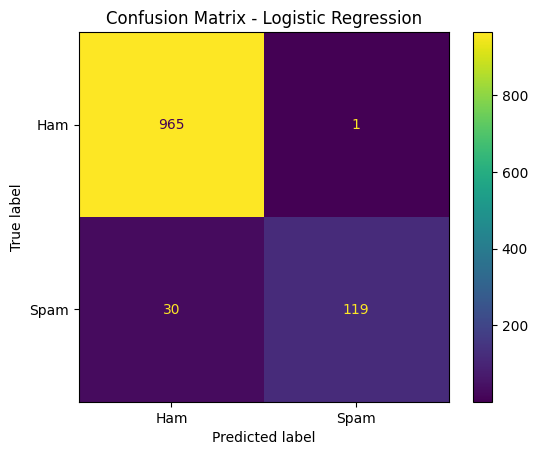

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [11]:
# Test the model with a new message

sample_message = ["Congratulations! You have won a free prize. Click now!"]

sample_tfidf = vectorizer.transform(sample_message)

prediction = lr_model.predict(sample_tfidf)

print("Prediction:", "Spam" if prediction[0] == 1 else "Ham")

Prediction: Spam


## Model Comparison and Conclusion

Two machine learning models were trained for email spam detection:

- Naive Bayes achieved an accuracy of 96.05%.
- Logistic Regression achieved an accuracy of 97.22%.

Logistic Regression performed better than Naive Bayes based on test accuracy and spam classification performance.

The final Logistic Regression model was also tested on a new message and successfully classified it as Spam.

### Conclusion

This project demonstrates how Natural Language Processing and Machine Learning can be used to classify messages as Spam or Ham. TF-IDF was used to convert text messages into numerical features, followed by machine learning classification using Naive Bayes and Logistic Regression.